### 1.	Generate Data (Pandas + NumPy)
	•	Create a dataset of 500 employees with the following columns:
	•	Employee_ID (1–500)
	•	Department (Random choice: HR, IT, Finance, Sales)
	•	Salary (10k to 50k)
	•	Experience_Years (Random integers between 1–20)
	•	Performance_Score (Random integers 1–5)
	•	Randomly introduce missing values in 10% of Salary and Experience_Years.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(1)
n=500
df=pd.DataFrame({
    "Employee_ID": np.arange(1,501),
    "Department": np.random.choice(["HR", "IT", "Finance", "Sales"], size=n),
    "Salary": np.random.randint(10000,50001,size=n),
    "Experience_Years": np.random.randint(1,21,size=n),
    "Performance_Score": np.random.randint(1,6,size=n)
})

sal_missing=np.random.choice(df.index,size=int(0.1*n),replace=False)
exp_missing=np.random.choice(df.index,size=int(0.1*n),replace=False)

df.iloc[sal_missing,2]=np.nan
df.iloc[exp_missing,3]=np.nan

print(df)

     Employee_ID Department   Salary  Experience_Years  Performance_Score
0              1         IT  32740.0              16.0                  3
1              2      Sales  47201.0               NaN                  1
2              3         HR  23058.0               6.0                  3
3              4         HR  25662.0               3.0                  4
4              5      Sales      NaN              20.0                  1
..           ...        ...      ...               ...                ...
495          496         HR  34876.0               1.0                  4
496          497         HR  42293.0               5.0                  2
497          498    Finance  15295.0               NaN                  2
498          499      Sales  37098.0               6.0                  5
499          500    Finance  37988.0              10.0                  2

[500 rows x 5 columns]


### 2.	Data Cleaning
	•	Identify missing values
	•	Fill missing Salary with the median of that department.
	•	Fill missing Experience_Years with the overall mean.

In [3]:
df["Salary"]=df.groupby("Department")["Salary"].transform(lambda x: x.fillna(x.median()))
df["Experience_Years"]=df["Experience_Years"].fillna(df["Experience_Years"].mean())
print(df["Salary"])
print(df["Experience_Years"])

0      32740.0
1      47201.0
2      23058.0
3      25662.0
4      33630.5
        ...   
495    34876.0
496    42293.0
497    15295.0
498    37098.0
499    37988.0
Name: Salary, Length: 500, dtype: float64
0      16.000000
1      10.597778
2       6.000000
3       3.000000
4      20.000000
         ...    
495     1.000000
496     5.000000
497    10.597778
498     6.000000
499    10.000000
Name: Experience_Years, Length: 500, dtype: float64


### 3.	Analysis
	•	Group employees by Department and calculate:
	•	Average Salary
	•	Average Performance Score
	•	Average Experience

In [5]:
analysis=df.groupby("Department").agg({
    "Salary": "mean",
    "Performance_Score": "mean",
    "Experience_Years": "mean"})
print(analysis)

                  Salary  Performance_Score  Experience_Years
Department                                                   
Finance     28419.183333           2.933333         10.811407
HR          31695.235294           2.933824         10.639542
IT          30773.286885           3.163934         10.755519
Sales       32244.409836           2.893443         10.183352


### 4.	Visualization (Matplotlib + Seaborn)
	•	Create a bar chart showing average salary per department.
	•	Create a boxplot of salaries across departments to check distribution.
	•	Create a scatter plot of Experience_Years vs Salary, colored by Performance_Score.

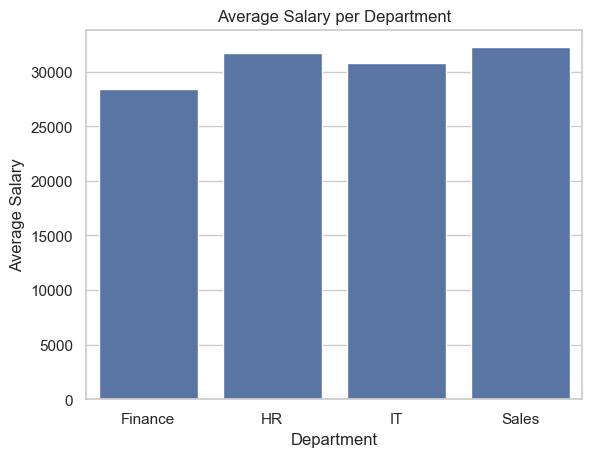

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_sal=df.groupby("Department")["Salary"].mean().reset_index()

sns.barplot(x="Department",y="Salary",data=avg_sal)
plt.title("Average Salary per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()



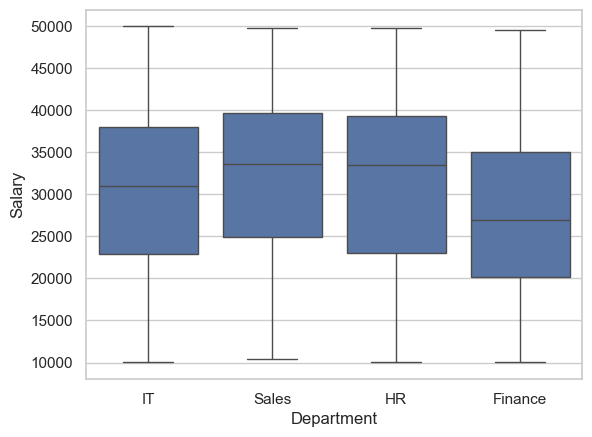

In [63]:
sns.boxplot(x="Department",y="Salary",data=df)
plt.show()

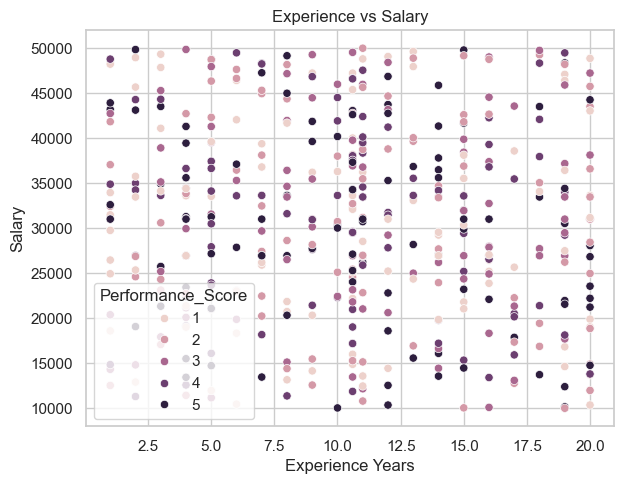

In [70]:
sns.scatterplot(x="Experience_Years",y="Salary",hue="Performance_Score",data=df)
plt.tight_layout()
plt.title("Experience vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()